# ResNet-18: From Scratch to Transfer Learning on CIFAR-100

This notebook provides a complete walkthrough of the project, exploring:
1. **Batch Normalization (BN)**: Impact on convergence and accuracy.
2. **Data Augmentation**: Interaction with BN.
3. **Transfer Learning**: Fine-tuning a pretrained model.
4. **Advanced Regularization**: Using Cutout and Mixup.
5. **Error Analysis**: Fine-grained vs. Superclass confusion.

In [1]:
# Check hardware
import torch
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Using device: cuda


## Phase 1: Batch Normalization & Augmentation

We compare four configurations:
- No BN, No Augmentation
- With BN, No Augmentation
- No BN, With Augmentation
- With BN, With Augmentation

In [2]:
# Run experiments (using 5 epochs for speed in walkthrough, use 10-20 for better results)
print("Running BN Comparison (No Augmentation)...")
!python compare_bn.py --epochs 5

print("\nRunning BN Comparison (With Augmentation)...")
!python compare_bn.py --aug --epochs 5

Running BN Comparison (No Augmentation)...
Using device: cuda | Augmentation: False
/home/ubuntu/anaconda3/envs/resnet_cifar/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Starting experiment: WITHOUT Batch Normalization (Augmentation: False)...
BN=False Epoch 1: 100%|██████████| 782/782 [00:06<00:00, 125.04it/s, Loss=1.038]
BN=False | Epoch 1 | Loss: 4.150 | Train Acc: 5.42% | Test Acc: 9.51%
BN=False Epoch 2: 100%|██████████| 782/782 [00:05<00:00, 144.54it/s, Loss=0.886]
BN=False | Epoch 2 | Loss: 3.541 | Train Acc: 15.18% | Test Acc: 17.84%
BN=False Epoch 3: 100%|██████████| 782/782 [00:05<00:00, 145.00it/s, Loss=0.799]
BN=False | Epoch 3 | Loss: 3.194 | Train Acc: 21.58% | Test Acc: 23.18%
BN=False Epoch 4: 100%|██████████| 782/782 [00:05<00:

Results without Augmentation:


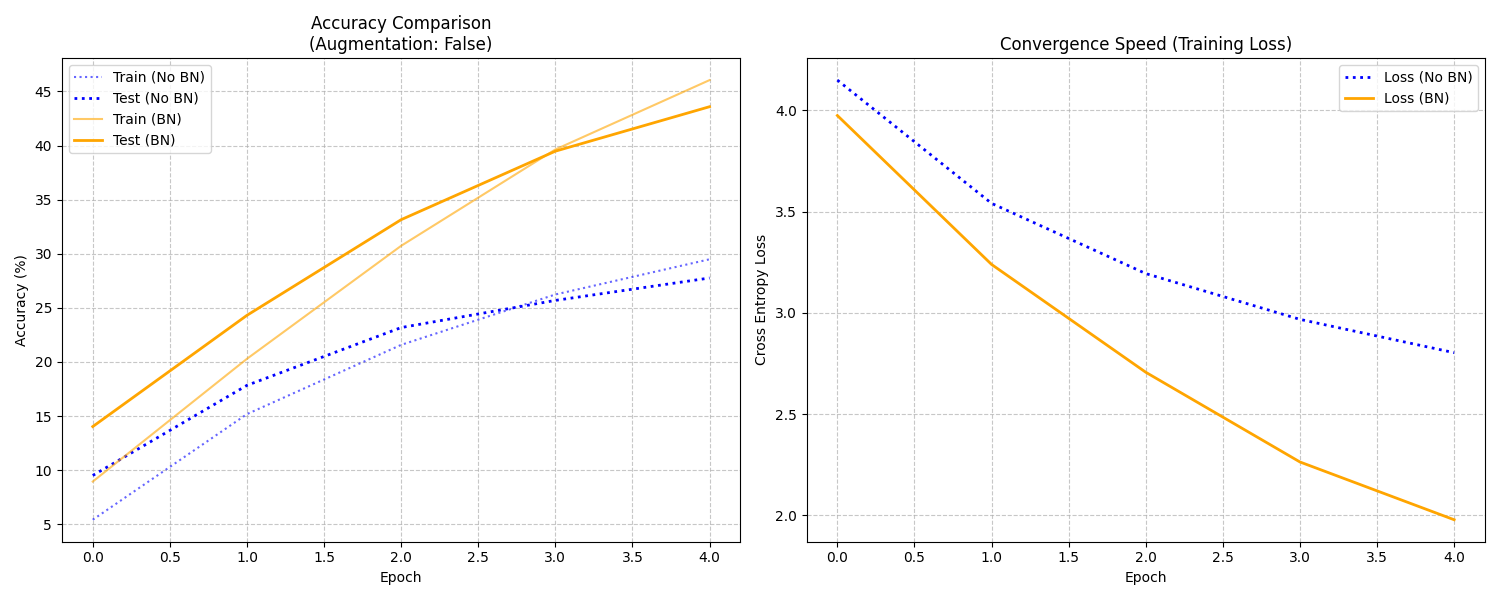

Results with Augmentation:


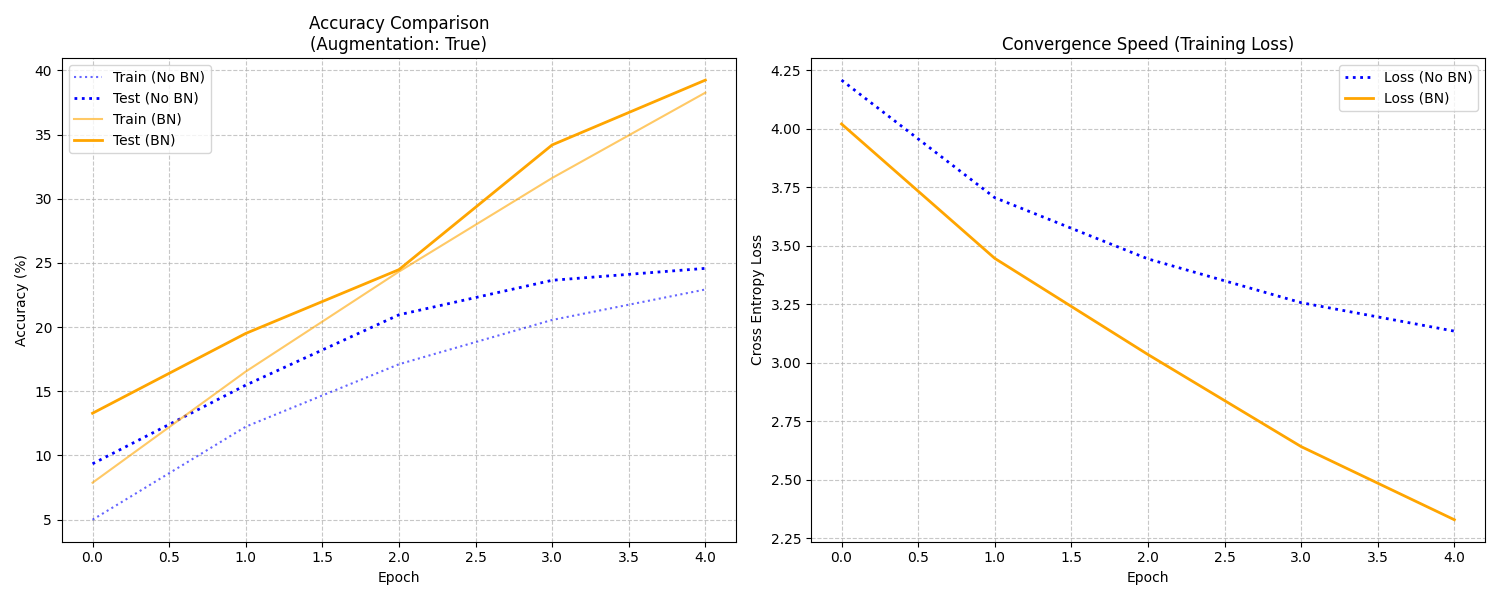

In [3]:
from IPython.display import Image, display
print("Results without Augmentation:")
display(Image(filename='bn_comparison_noaug.png'))
print("Results with Augmentation:")
display(Image(filename='bn_comparison_aug.png'))

## Phase 2: Transfer Learning

Comparing a basic fine-tuning approach with a refined version (`v2`) that uses larger input sizes (224x224) and more aggressive augmentation.

In [4]:
print("Running Basic Transfer Learning...")
!python transfer_learning.py

print("\nRunning Refined Transfer Learning (v2)...")
!python train_v2.py

Running Basic Transfer Learning...
🚀 Transfer Learning running on: CUDA
/home/ubuntu/anaconda3/envs/resnet_cifar/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 1: 100%|████████| 782/782 [00:28<00:00, 27.03it/s, Acc=46.87%, Loss=1.968]
Test Acc: 54.99%
Epoch 2: 100%|████████| 782/782 [00:28<00:00, 27.39it/s, Acc=65.85%, Loss=1.169]
Test Acc: 63.41%
Epoch 3: 100%|████████| 782/782 [00:28<00:00, 27.45it/s, Acc=74.57%, Loss=0.827]
Test Acc: 64.13%
Epoch 4: 100%|████████| 782/782 [00:28<00:00, 27.16it/s, Acc=82.03%, Loss=0.575]
Test Acc: 66.91%
Epoch 5: 100%|████████| 782/782 [00:28<00:00, 27.18it/s, Acc=87.61%, Loss=0.389]
Test Acc: 66.89%

Running Refined Transfer Learning (v2)...
Test  Epoch 1: 100%|██| 157/157 [00:03<00:00, 40.29it/s, Acc=50

## Phase 3: Advanced Training (Week 3)

Training the scratch model with **Mixup**, **Cutout**, and **Cosine Annealing**.

In [5]:
print("Running Advanced Training...")
!python train_advanced.py

Running Advanced Training...
/home/ubuntu/anaconda3/envs/resnet_cifar/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")

Epoch: 1
100%|█████████████████████████████| 391/391 [00:05<00:00, 69.27it/s, Loss=4.347]
Test Acc: 9.45%
Saving..

Epoch: 2
100%|█████████████████████████████| 391/391 [00:05<00:00, 72.39it/s, Loss=4.084]
Test Acc: 13.10%
Saving..

Epoch: 3
100%|█████████████████████████████| 391/391 [00:05<00:00, 72.64it/s, Loss=3.916]
Test Acc: 19.86%
Saving..

Epoch: 4
100%|█████████████████████████████| 391/391 [00:05<00:00, 72.55it/s, Loss=3.760]
Test Acc: 20.68%
Saving..

Epoch: 5
100%|█████████████████████████████| 391/391 [00:05<00:00, 72.67it/s, Loss=3.638]
Test Acc: 20.88%
Saving..

Epoch: 6
100%|█████████████████████████████| 391/391 [

## Phase 4: Final Comparison

Aggregating all results into a single comprehensive view.

Saved comprehensive comparison plot (Accuracy & Loss) to 'final_comparison_plot.png'

Experiment                          | Best Test Acc (%)
------------------------------------------------------------
Advanced                            | 65.81          
With Bn Noaug                       | 43.59          
No Bn Aug                           | 24.58          
Transfer                            | 66.91          
With Bn Aug                         | 39.25          
No Bn Noaug                         | 27.76          


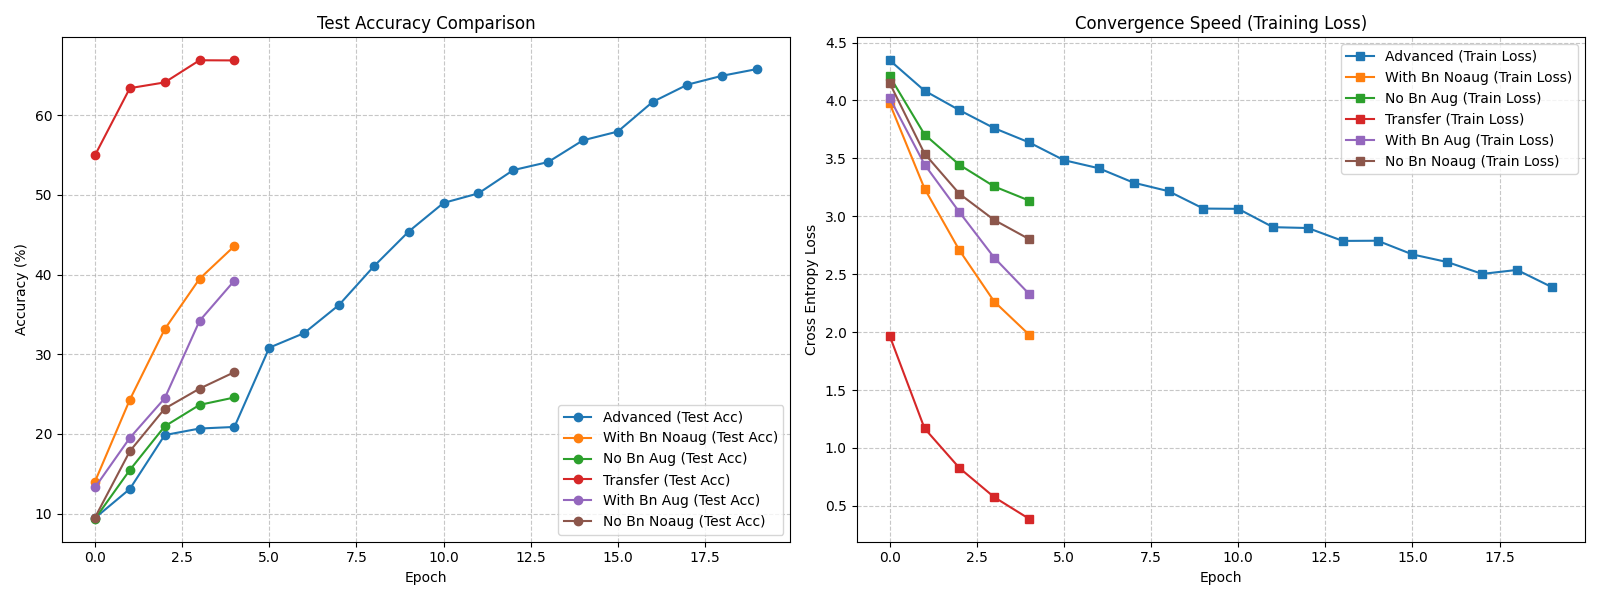

In [6]:
!python final_comparison.py
display(Image(filename='final_comparison_plot.png'))

## Phase 5: Error Analysis

Visualizing the confusion matrix at the superclass level for the best model.

Detected Torchvision architecture
/home/ubuntu/anaconda3/envs/resnet_cifar/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Running evaluation...
Fine-grained Accuracy: 78.70%
Superclass Accuracy: 87.29%
Saved superclass confusion matrix as 'superclass_confusion.png'

Top 10 most frequent fine-class confusions:
Actual: maple_tree      | Predicted: oak_tree        | Count: 16
Actual: snake           | Predicted: worm            | Count: 15
Actual: girl            | Predicted: boy             | Count: 15
Actual: boy             | Predicted: man             | Count: 15
Actual: baby            | Predicted: boy             | Count: 14
Actual: pine_tree       | Predicted: oak_tree        | Count: 14
Actual: boy             | Predicted: girl            | 

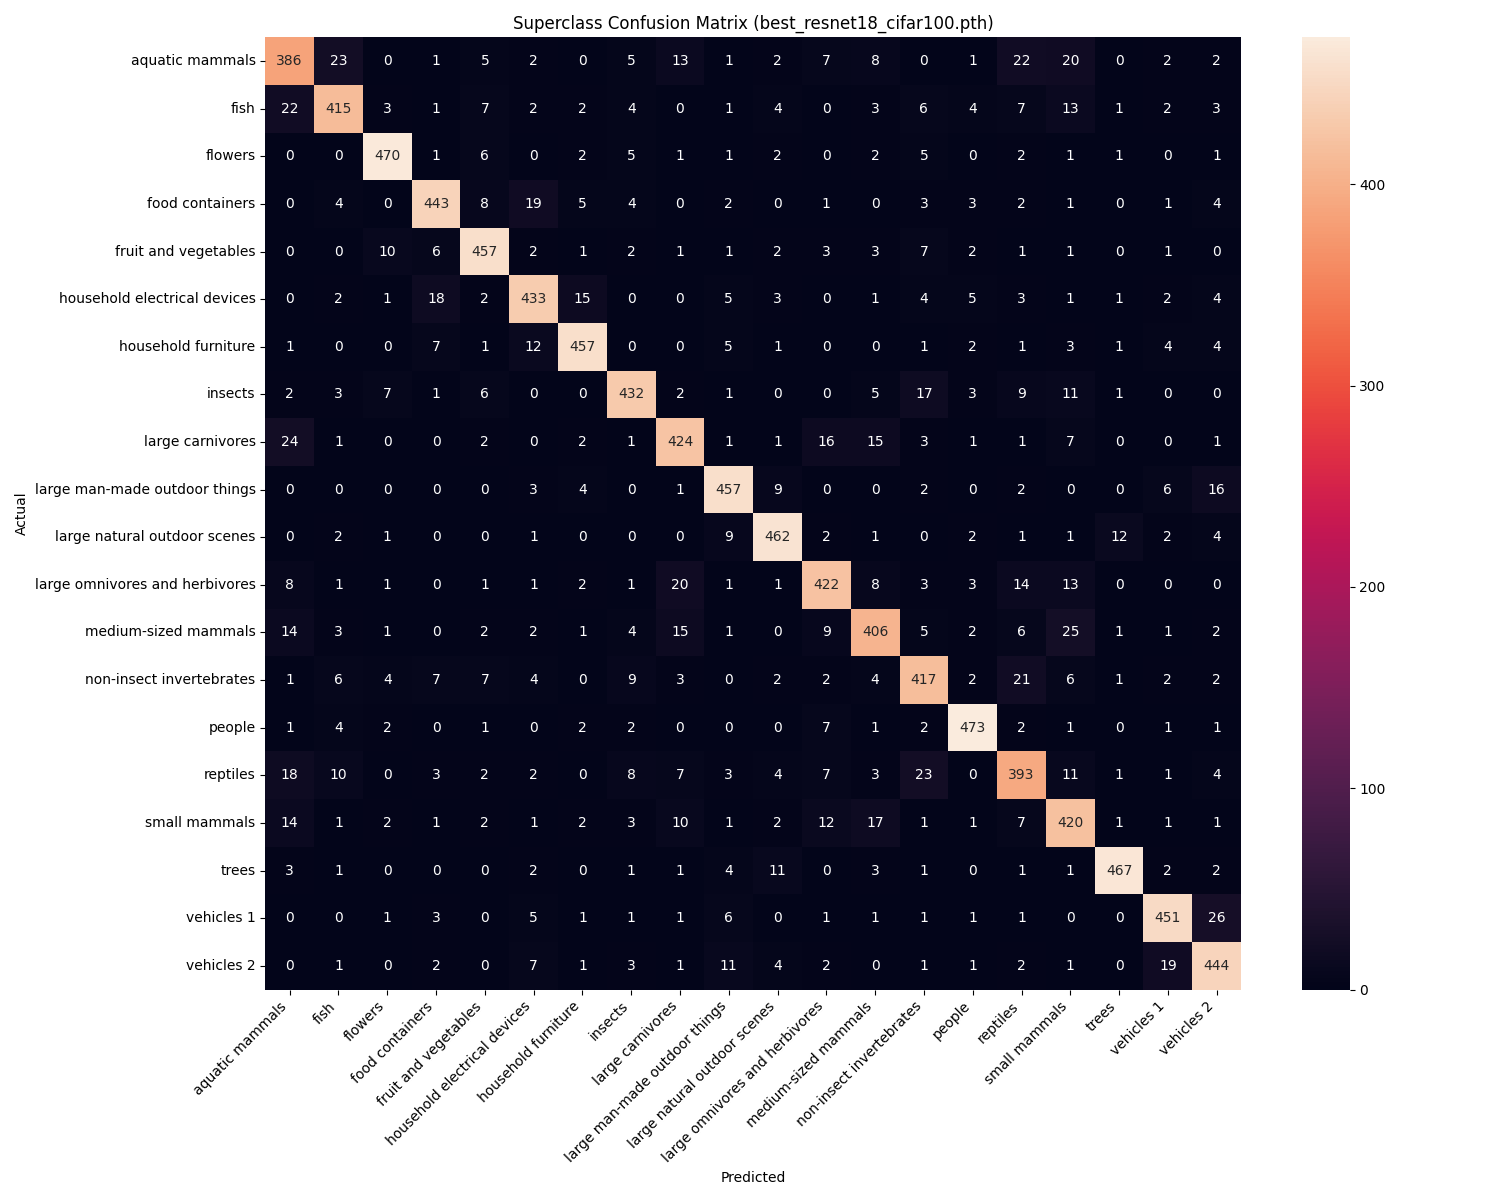

In [7]:
!python analyze_errors.py
display(Image(filename='superclass_confusion.png'))